## Data Loading

In [1]:
import pandas as pd
df = pd.read_csv(r'C:\Users\Fatma\Downloads\nlp course\english dataset\sentiment_data.csv')
df.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [2]:
df.columns

Index(['Unnamed: 0', 'Comment', 'Sentiment'], dtype='object')

In [3]:
df.isnull().sum()

Unnamed: 0      0
Comment       217
Sentiment       0
dtype: int64

## Data cleaning and preprocessing

In [4]:
import nltk 
import string 
import re
from nltk import word_tokenize,sent_tokenize,WordNetLemmatizer,pos_tag
from nltk.corpus import stopwords, wordnet

In [5]:
df['Comment'] = df['Comment'].fillna("")
df['Comment'] = df['Comment'].str.lower()
df['Comment'] = df['Comment'].str.replace(r"\d+", "", regex=True)



def get_pos(tag):
    if tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    elif tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('N'):
        return wordnet.NOUN
    return wordnet.NOUN


def preprocessing(Comment):

    stop_words = set(stopwords.words('english'))
    punctuation = set(string.punctuation)

    Comment = re.sub(r'\s+', ' ', Comment).strip()

    lemmatizer = WordNetLemmatizer()

    sentences = sent_tokenize(Comment)
    clean_sentences = []

    for i in sentences:

        tokens = word_tokenize(i)
        tags = pos_tag(tokens)

        new_tokens = [lemmatizer.lemmatize(word, get_pos(tag)) for word, tag in tags
            if (word not in punctuation) and (word not in stop_words)]

        new_sentence = ' '.join(new_tokens)
        clean_sentences.append(new_sentence)

    return '.'.join(clean_sentences)


df["clean_Comments"] = df['Comment'].apply(preprocessing)
   



In [6]:
df['clean_Comments'].head()

0    let forget apple pay require brand new iphone ...
1    nz retailer ’ even contactless credit card mac...
2    forever acknowledge channel help lesson ideas ...
3    whenever go place ’ take apple pay ’ happen of...
4    apple pay convenient secure easy use used kore...
Name: clean_Comments, dtype: object

In [7]:
df['clean_Comments'] = df['clean_Comments'].str.replace(r"[^\w\s]", "", regex=True)

In [8]:
df['clean_Comments'].head()

0    let forget apple pay require brand new iphone ...
1    nz retailer  even contactless credit card mach...
2    forever acknowledge channel help lesson ideas ...
3    whenever go place  take apple pay  happen ofte...
4    apple pay convenient secure easy use used kore...
Name: clean_Comments, dtype: object

## EDA

Class Distribution analysis

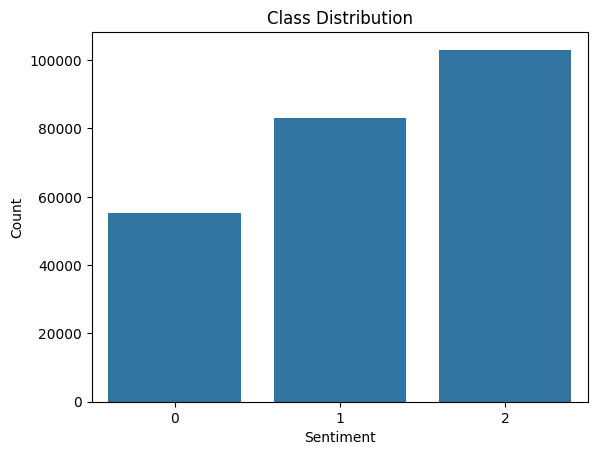

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Sentiment',data=df)

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Text Length Distribution

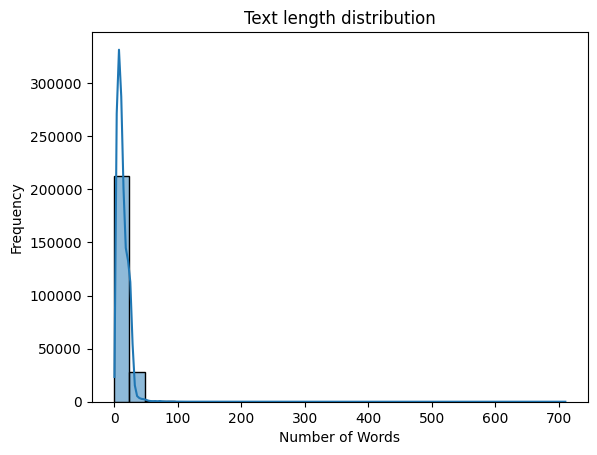

In [10]:
df['text_length'] = df['clean_Comments'].apply(lambda x: len(str(x).split()))

sns.histplot(df['text_length'], bins=30, kde=True)

plt.title("Text length distribution")

plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Most frequent words per class

In [11]:
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

for label in df['Sentiment'].unique():

    texts = df[df['Sentiment'] == label]['clean_Comments']

    all_words = " ".join(texts).split()

    filtered_words = [
        word for word in all_words
        if word not in stop_words
    ]

    top_words = Counter(filtered_words).most_common(5)

    print(f"\nTop words in class {label}:")
    for word, freq in top_words:
        print(word, ":", freq)


Top words in class 1:
modi : 47832
india : 6562
get : 5835
say : 5808
like : 5076

Top words in class 0:
modi : 33901
india : 6168
get : 5480
like : 5225
people : 4838

Top words in class 2:
modi : 67947
india : 15599
like : 9522
good : 9514
get : 8985


word cloud visualization

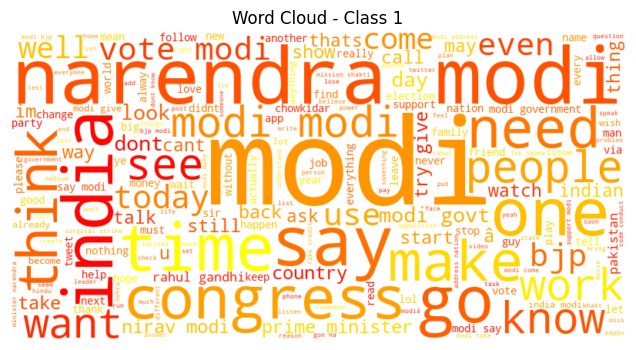

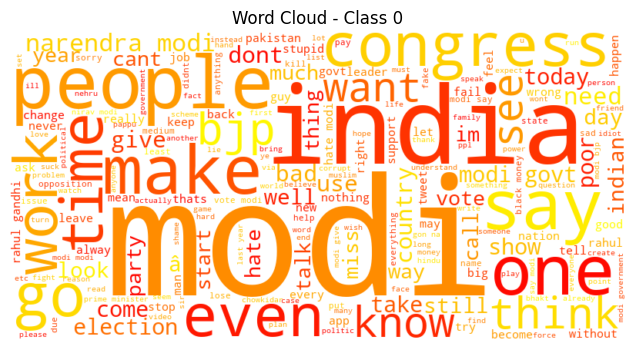

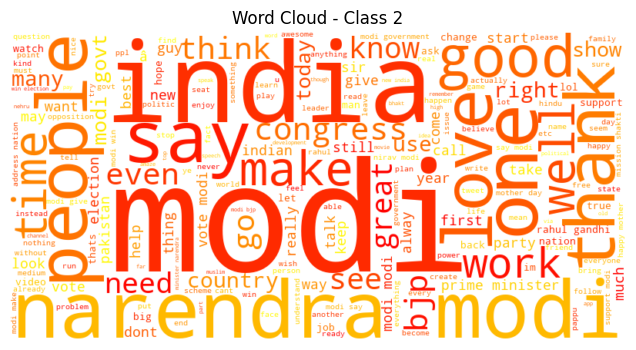

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for label in df['Sentiment'].unique():

    text = " ".join(df[df['Sentiment'] == label]['clean_Comments'])

    wordcloud = WordCloud(width=800,height=400,background_color='white',colormap='autumn').generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud - Class {label}")
    plt.show()

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(ngram_range=(1,2))
x=cv.fit_transform(df['clean_Comments'])


In [16]:
y=df['Sentiment']

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2)

In [18]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [20]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(cv, open("vectorizer.pkl", "wb"))


In [21]:
from sklearn.metrics import classification_report
y_pred= model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.17      0.29     10982
           1       0.81      0.35      0.49     16550
           2       0.52      0.98      0.68     20697

    accuracy                           0.58     48229
   macro avg       0.76      0.50      0.49     48229
weighted avg       0.72      0.58      0.52     48229



<Axes: >

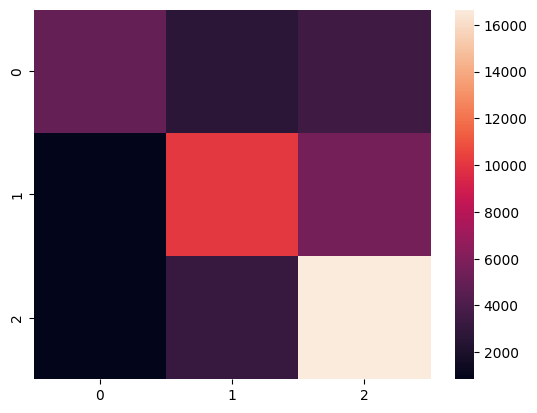

: 

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 

sns.heatmap(confusion_matrix(y_test,y_pred))

In [ ]:
import joblib
joblib.dump(model, "english_model.pkl")
joblib.dump(cv, "tfidf_en.pkl")

['tfidf_en.pkl']

: 